In [1]:
import sqlite3
from collections import Counter, defaultdict
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)

cur = conn.execute("""
    SELECT occupations_en, birthdate
    FROM individuals
    WHERE occupations_en LIKE '%astronomer%'
      AND birthdate IS NOT NULL
""")

astronomer_variants = {'amateur astronomer', 'radio astronomer',
                       'archaeoastronomer', 'astronomer royal'}

periods = {
    '750 – 1250':  (750, 1250),
    '1400 – 1650': (1400, 1650),
    '1750 – 1950': (1750, 1950),
}

# Per period: count each occupation and every pair on the same person
occ_counts = {name: Counter() for name in periods}
pair_counts = {name: Counter() for name in periods}
n_astro = {name: 0 for name in periods}

for occs_str, bdate in cur:
    try:
        year = int(bdate[:4])
    except (ValueError, TypeError):
        continue
    for name, (y0, y1) in periods.items():
        if y0 <= year <= y1:
            n_astro[name] += 1
            # Keep "astronomer" itself as a node now
            occs = [o.strip() for o in occs_str.split('; ')
                    if o.strip() and o.strip().lower() not in astronomer_variants]
            for occ in occs:
                occ_counts[name][occ] += 1
            for a, b in combinations(sorted(occs), 2):
                pair_counts[name][(a, b)] += 1
            break

conn.close()

for name in periods:
    print(f"{name}: {n_astro[name]} astronomers, "
          f"{len(occ_counts[name])} unique occupations, "
          f"{len(pair_counts[name])} unique pairs")

750 – 1250: 171 astronomers, 105 unique occupations, 893 unique pairs
1400 – 1650: 678 astronomers, 223 unique occupations, 2097 unique pairs
1750 – 1950: 5328 astronomers, 490 unique occupations, 3431 unique pairs


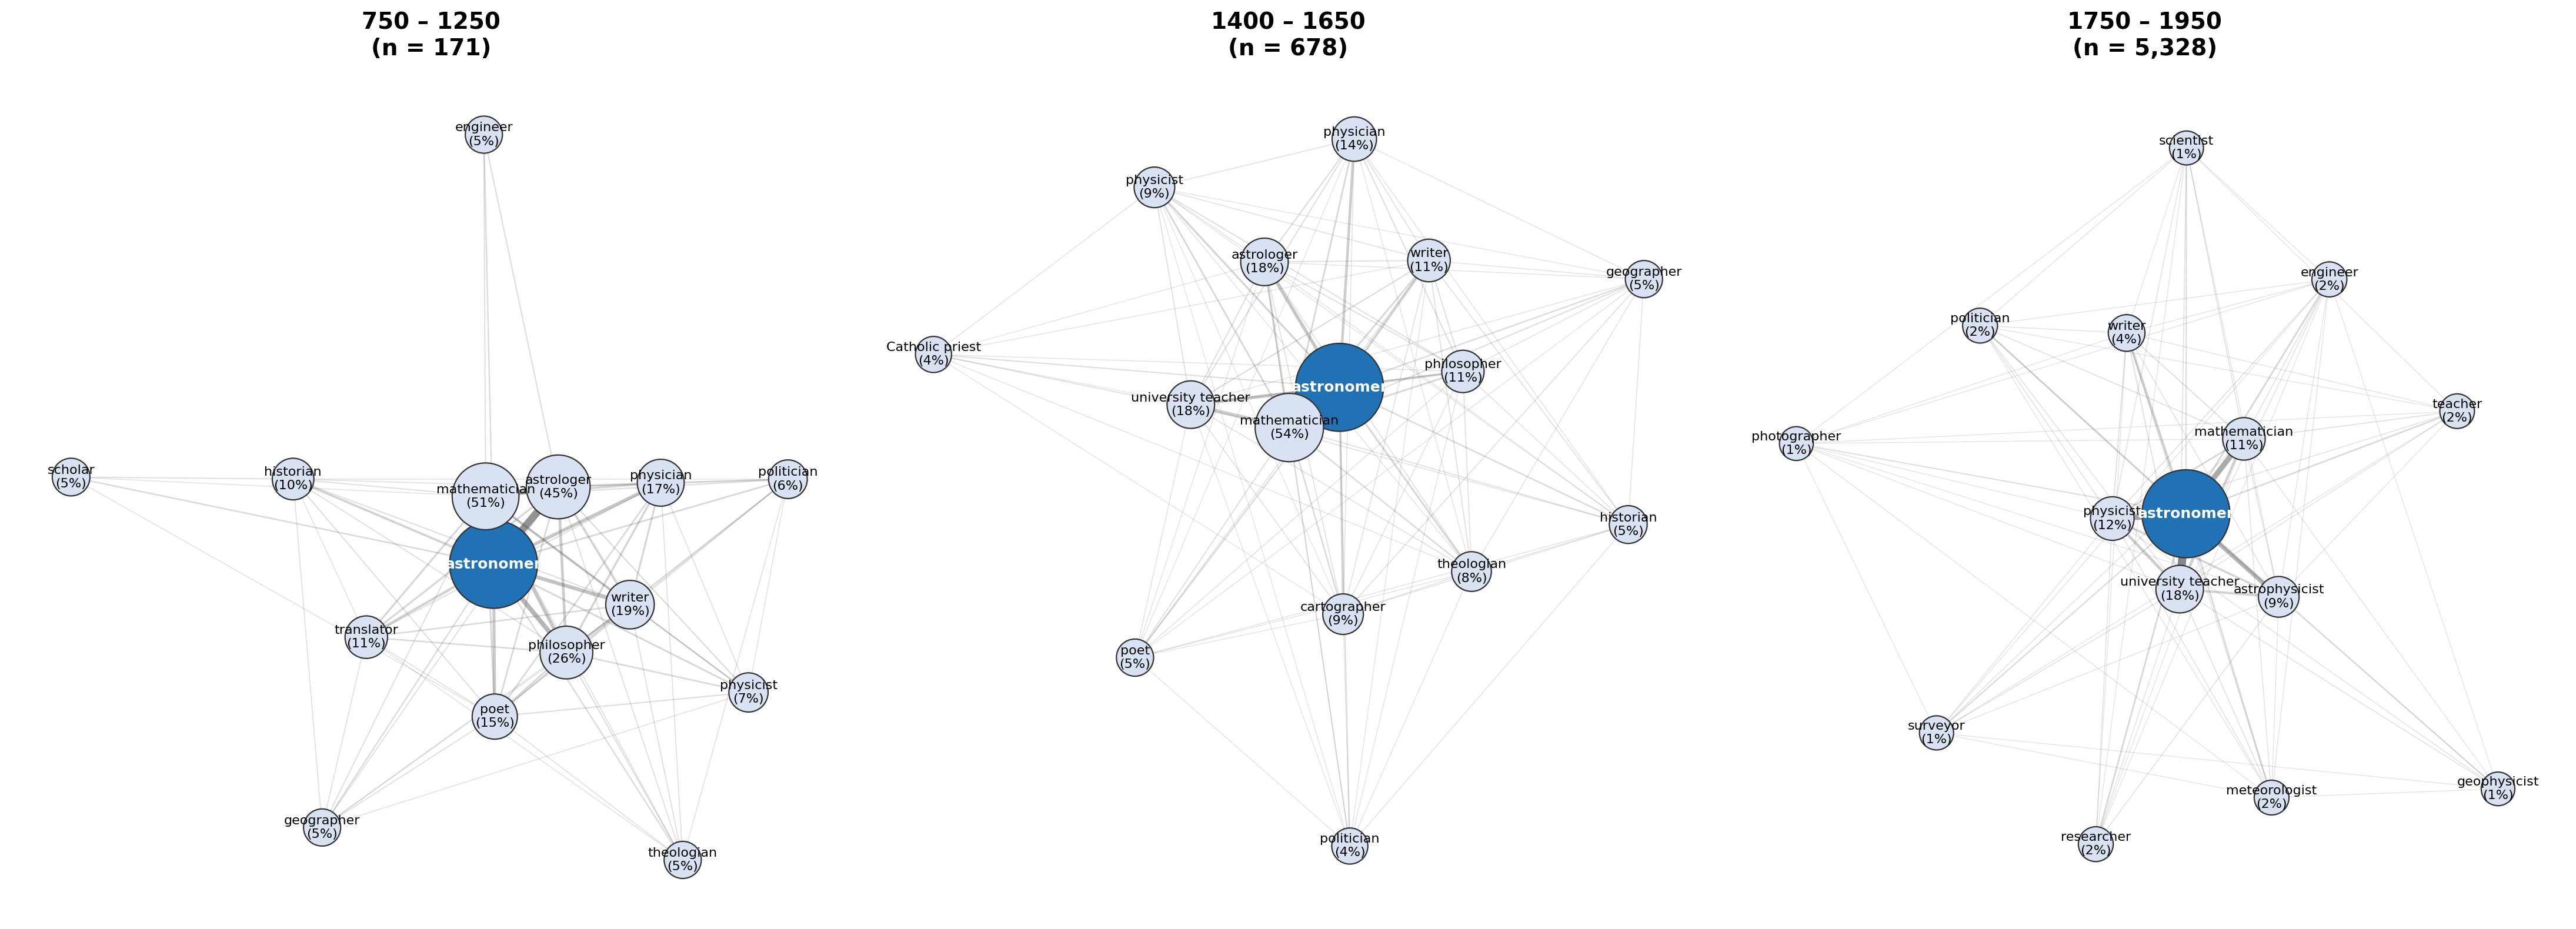

In [2]:
# ── 3-panel co-occurrence network (astronomer included as node) ──
N_NODES = 15

fig, axes = plt.subplots(1, 3, figsize=(22, 8), dpi=200)

for ax, name in zip(axes, periods):
    # Top N occupations; ensure "astronomer" is always included
    top_occs = [occ for occ, _ in occ_counts[name].most_common(N_NODES)]
    if 'astronomer' not in top_occs:
        top_occs = ['astronomer'] + top_occs[:N_NODES - 1]
    top_set = set(top_occs)

    G = nx.Graph()
    for occ in top_occs:
        G.add_node(occ, count=occ_counts[name][occ])

    for (a, b), cnt in pair_counts[name].items():
        if a in top_set and b in top_set and cnt >= 2:
            G.add_edge(a, b, weight=cnt)

    pos = nx.spring_layout(G, k=2.0, iterations=150, seed=42, weight='weight')

    # Node sizes proportional to frequency
    counts = [G.nodes[n]['count'] for n in G.nodes()]
    max_c = max(counts)
    node_sizes = [400 + 2500 * (c / max_c) for c in counts]

    # Node colors: highlight astronomer
    node_colors = ['#2171b5' if n == 'astronomer' else '#d9e2f3'
                   for n in G.nodes()]

    # Edge widths
    if G.edges():
        edge_weights = [G.edges[e]['weight'] for e in G.edges()]
        max_ew = max(edge_weights)
        edge_widths = [0.5 + 4.5 * (w / max_ew) for w in edge_weights]
        edge_alphas = [0.15 + 0.55 * (w / max_ew) for w in edge_weights]
    else:
        edge_widths, edge_alphas = [], []

    for (u, v), ew, ea in zip(G.edges(), edge_widths, edge_alphas):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax,
                               width=ew, edge_color='#555555', alpha=ea)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, edgecolors='#333333',
                           linewidths=0.8)

    # Labels: astronomer shows just the name (no percent), others show percent
    n = n_astro[name]
    other_labels = {}
    astro_labels = {}
    for occ in G.nodes():
        if occ == 'astronomer':
            astro_labels[occ] = 'astronomer'
        else:
            other_labels[occ] = f"{occ}\n({occ_counts[name][occ]/n:.0%})"

    nx.draw_networkx_labels(G, pos, labels=other_labels, ax=ax, font_size=8,
                            font_color='black')
    nx.draw_networkx_labels(G, pos, labels=astro_labels, ax=ax, font_size=9,
                            font_color='white', font_weight='bold')

    ax.set_title(f"{name}\n(n = {n:,})", fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

plt.tight_layout()
plt.show()